<a href="https://colab.research.google.com/github/LucianoBV/Procesamiento-del-habla/blob/main/P_N_L_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 - Extracción y análisis de información desde PDF

## Alumno: Luciano Vargas

## Materia: Procesamiento del Habla

### Objetivo: Desarrollar un flujo de trabajo en Python que permita descargar un archivo PDF, extraer su contenido y aplicar técnicas básicas de análisis de texto.

### Instalación de librerías

Se instalaron las librerías necesarias para trabajar con archivos PDF y procesamiento de texto.

En particular:
- requests para descarga
- PyMuPDF para manipular el PDF
- nltk para el análisis de texto
- pdfplumber para extracción de tablas
- pandas para crear data frame
- matplotlib para graficar

# 🔹1. Adquisición y metadatos
## Descarga del archivo PDF

En esta etapa se descargó un archivo PDF desde un enlace público utilizando la librería requests.

Este proceso permite automatizar la adquisición del documento, evitando la descarga manual y facilitando la reproducibilidad del análisis.

In [ ]:
import requests

# Enlace del PDF
url_pdf = "https://arxiv.org/pdf/2509.09467"

# Nombre con el que se guardará en la carpeta del proyecto
nombre_archivo = "tp1_documento.pdf"

# Descargar el archivo
respuesta = requests.get(url_pdf)

if respuesta.status_code == 200:
    with open(nombre_archivo, "wb") as archivo:
        archivo.write(respuesta.content)
    print(f"PDF descargado correctamente como: {nombre_archivo}")
else:
    print(f"Error al descargar el PDF. Código de estado: {respuesta.status_code}")

PDF descargado correctamente como: tp1_documento.pdf


In [ ]:
!pip install PyMuPDF # Tube que instalar PyMuPDF con pip porque no viene por defecto.

## Inspección de metadatos

Se utilizó la librería PyMuPDF para abrir el documento y acceder a sus metadatos.

Los metadatos permiten obtener información relevante como:
- título del documento
- autor
- software de creación
- cantidad de páginas

Esta información ayuda a comprender el origen y estructura general del archivo antes de analizar su contenido.

In [ ]:
import fitz  # PyMuPDF

# Abrir el PDF descargado
doc = fitz.open("tp1_documento.pdf")

# Obtener metadatos
metadatos = doc.metadata

# Mostrar por pantalla
print("Título:", metadatos.get("title"))
print("Autor:", metadatos.get("author"))
print("Software de creación:", metadatos.get("creator"))
print("Productor:", metadatos.get("producer"))
print("Número de páginas:", doc.page_count)

Título: Inteligencia Artificial jur\'idica y el desaf\'io de la veracidad: an\'alisis de alucinaciones, optimizaci\'on de RAG y principios para una integraci\'on responsable
Autor: Alex Dantart
Software de creación: arXiv GenPDF (tex2pdf:)
Productor: pikepdf 8.15.1
Número de páginas: 118


# 🔹2. Análisis estructural del texto

## Extracción de texto (forma cruda)

Se extrajo el texto de las primeras páginas del documento.

El texto obtenido es considerado crudo, ya que se obtiene directamente del PDF sin ningún tipo de procesamiento.

Esto implica que puede contener: saltos de línea, espacios irregulares, cortes de palabras

In [ ]:
# Abrir el PDF
doc = fitz.open("tp1_documento.pdf")

texto_completo = ""

# Recorrer las primeras 5 páginas
for i in range(5):
    pagina = doc[i]  # acceder a la página
    texto = pagina.get_text()  # extraer texto
    texto_completo += texto

# Mostrar el texto crudo
print(texto_completo)

INTELIGENCIA ARTIFICIAL JURÍDICA Y EL DESAFÍO DE LA
VERACIDAD: ANÁLISIS DE ALUCINACIONES, OPTIMIZACIÓN DE
RAG Y PRINCIPIOS PARA UNA INTEGRACIÓN RESPONSABLE
INFORME TÉCNICO
Alex Dantart
CIO LittleJohn
Paseo de la Castellana 194
28046, Madrid, España
arxiv@littlejohn.ai
ABSTRACT
Los grandes modelos de lenguaje (LLMs) están redeﬁniendo aceleradamente la práctica, la educación
y la investigación jurídicas. Sin embargo, su vasto potencial se ve signiﬁcativamente amenazado por
la generación endémica de "alucinaciones" – resultados textuales que, aunque a menudo plausibles,
son fácticamente incorrectos, engañosos o inconsistentes con las fuentes legales autorizadas. Este
ensayo presenta una revisión exhaustiva y un análisis crítico multidimensional del fenómeno de las
alucinaciones en LLMs aplicados al derecho. Se documentan las tendencias y manifestaciones de
las alucinaciones a través de jurisdicciones, tipos de tribunales y clases de tareas legales, fundamen-
tándonos en la creciente evide





## Análisis de estructura del texto

Para analizar la estructura del texto, se utilizó la función repr(), que permite visualizar caracteres especiales.

### Separadores identificados

 \n: salto de línea

 \n\n: separación de párrafos


In [ ]:
pagina = doc[0]  # elijo pagina
texto = pagina.get_text()

# Mostrar texto con caracteres visibles
print(repr(texto[:1000]))  # mostramos los primeros 1000 caracteres

'INTELIGENCIA ARTIFICIAL JURÍDICA Y EL DESAFÍO DE LA\nVERACIDAD: ANÁLISIS DE ALUCINACIONES, OPTIMIZACIÓN DE\nRAG Y PRINCIPIOS PARA UNA INTEGRACIÓN RESPONSABLE\nINFORME TÉCNICO\nAlex Dantart\nCIO LittleJohn\nPaseo de la Castellana 194\n28046, Madrid, España\narxiv@littlejohn.ai\nABSTRACT\nLos grandes modelos de lenguaje (LLMs) están redeﬁniendo aceleradamente la práctica, la educación\ny la investigación jurídicas. Sin embargo, su vasto potencial se ve signiﬁcativamente amenazado por\nla generación endémica de "alucinaciones" – resultados textuales que, aunque a menudo plausibles,\nson fácticamente incorrectos, engañosos o inconsistentes con las fuentes legales autorizadas. Este\nensayo presenta una revisión exhaustiva y un análisis crítico multidimensional del fenómeno de las\nalucinaciones en LLMs aplicados al derecho. Se documentan las tendencias y manifestaciones de\nlas alucinaciones a través de jurisdicciones, tipos de tribunales y clases de tareas legales, fundamen-\ntándonos en 

# 🔹3. Extracción de datos tabulares

# Se utilizó la librería pdfplumber para extraer una tabla presente en el documento.


## Luego, se convirtió en un DataFrame de Pandas para facilitar su análisis.


In [ ]:
!pip install pdfplumber pandas

In [ ]:
import pdfplumber
import pandas as pd

# Abrir el PDF
with pdfplumber.open("tp1_documento.pdf") as pdf:
    # Página 4 del documento = índice 3 en Python
    pagina = pdf.pages[3]

    # Extraer la tabla
    tabla = pagina.extract_table()

# Convertir la tabla a DataFrame
df_tabla = pd.DataFrame(tabla)

# Ver la tabla cruda
print("Tabla cruda:")
display(df_tabla)

Tabla cruda:


,0,1,2
0,Característica,IAgenerativa(propósitogeneral),IAconsultiva(especializada)
1,Objetivoprincipal,Fluidezycoherenciaconversacional.,"Precisión,fiabilidadyfundamentación."
2,Fuentedeconocimiento,"Paramétrico,interno,estático(""libro\ncerrado"").","Externo,curado,dinámico(""libro\nabierto"")."
3,Riesgodealucinación,"Alto,especialmentefabricaciónde\nhechos(""dedis...","Bajoenfabricación,riesgode\nmisgrounding."
4,Transparencia,"Baja(""cajanegra"").",Alta(debecitarfuentesy\nrazonamiento).
5,Casodeusoideal,"Brainstorming,borradorescreativos,\ntareasnocr...","Investigaciónjurídica,duediligence,\nrespuesta..."
6,Analogía,"Un""sabelotodo""elocuenteperoaveces\npocofiable.","Un""archivero""meticulosoquesiempre\nmuestrasusf..."




## Limpieza realizada
se asignaron nombres de columnas

se eliminaron filas vacías

se reinició el índice

In [ ]:
# Tomar la primera fila como encabezado
df_tabla.columns = df_tabla.iloc[0]

# Eliminar la primera fila, que ya pasó a ser encabezado
df_tabla = df_tabla[1:].copy()

# Eliminar filas completamente vacías
df_tabla.dropna(how="all", inplace=True)

# Reiniciar índices
df_tabla.reset_index(drop=True, inplace=True)

# Reemplazar saltos de línea dentro de las celdas
df_tabla = df_tabla.replace(r'\n', ' ', regex=True)

# Quitar espacios innecesarios al inicio y al final
df_tabla = df_tabla.applymap(lambda x: x.strip() if isinstance(x, str) else x)

print("Tabla limpia:")
display(df_tabla)

Tabla limpia:


/tmp/ipykernel_623/801711484.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_tabla = df_tabla.applymap(lambda x: x.strip() if isinstance(x, str) else x)


,Característica,IAgenerativa(propósitogeneral),IAconsultiva(especializada)
0,Objetivoprincipal,Fluidezycoherenciaconversacional.,"Precisión,fiabilidadyfundamentación."
1,Fuentedeconocimiento,"Paramétrico,interno,estático(""libro cerrado"").","Externo,curado,dinámico(""libro abierto"")."
2,Riesgodealucinación,"Alto,especialmentefabricaciónde hechos(""dedise...","Bajoenfabricación,riesgode misgrounding."
3,Transparencia,"Baja(""cajanegra"").",Alta(debecitarfuentesy razonamiento).
4,Casodeusoideal,"Brainstorming,borradorescreativos, tareasnocrí...","Investigaciónjurídica,duediligence, respuestas..."
5,Analogía,"Un""sabelotodo""elocuenteperoaveces pocofiable.","Un""archivero""meticulosoquesiempre muestrasusfi..."


# 🔹4. Análisis de frecuencias (NLP básico)



## Tokenización del texto

Se seleccionó una página con texto narrativo y se aplicó tokenización utilizando la librería nltk.

Primero, el texto se convirtió a minúsculas para evitar duplicaciones.

Luego, se dividio el texto en palabras individuales llamadas tokens.

In [ ]:
!pip install nltk

In [ ]:
import nltk
from nltk.corpus import stopwords
import string
# Descargar recursos necesarios
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Abrir el PDF
doc = fitz.open("tp1_documento.pdf")

# Elegir una página (por ejemplo la 1 = índice 0)
pagina = doc[0]

# Extraer texto
texto = pagina.get_text()

# Convertir a minúsculas
texto = texto.lower()

# Tokenizar (separar en palabras)
tokens = nltk.word_tokenize(texto)

# Mostrar algunos tokens
print(tokens[:50])

['inteligencia', 'artificial', 'jurídica', 'y', 'el', 'desafío', 'de', 'la', 'veracidad', ':', 'análisis', 'de', 'alucinaciones', ',', 'optimización', 'de', 'rag', 'y', 'principios', 'para', 'una', 'integración', 'responsable', 'informe', 'técnico', 'alex', 'dantart', 'cio', 'littlejohn', 'paseo', 'de', 'la', 'castellana', '194', '28046', ',', 'madrid', ',', 'españa', 'arxiv', '@', 'littlejohn.ai', 'abstract', 'los', 'grandes', 'modelos', 'de', 'lenguaje', '(', 'llms']





## Limpieza del texto

Se eliminaron stopwords y signos de puntuación para obtener palabras más relevantes.

### Stopwords
Se utilizaron stopwords en español, que incluyen palabras como:
- el
- de
- y

### Puntuación
Se eliminaron caracteres como:
 .  ,  ;  :  !  ?

Esto permite enfocarse en palabras con mayor contenido semántico.

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Lista de stopwords en español
stop_words = set(stopwords.words('spanish'))

# Lista de signos de puntuación
signos = set(string.punctuation)

# Filtrado
tokens_limpios = []

for palabra in tokens:
    if palabra not in stop_words and palabra not in signos:
        tokens_limpios.append(palabra)

# Mostrar resultado
print(tokens_limpios[:50])

['inteligencia', 'artificial', 'jurídica', 'desafío', 'veracidad', 'análisis', 'alucinaciones', 'optimización', 'rag', 'principios', 'integración', 'responsable', 'informe', 'técnico', 'alex', 'dantart', 'cio', 'littlejohn', 'paseo', 'castellana', '194', '28046', 'madrid', 'españa', 'arxiv', 'littlejohn.ai', 'abstract', 'grandes', 'modelos', 'lenguaje', 'llms', 'redeﬁniendo', 'aceleradamente', 'práctica', 'educación', 'investigación', 'jurídicas', 'embargo', 'vasto', 'potencial', 've', 'signiﬁcativamente', 'amenazado', 'generación', 'endémica', '``', 'alucinaciones', "''", '–', 'resultados']


## Visualización y Análisis de frecuencias

Se contó la frecuencia de aparición de cada palabra utilizando Counter.

Luego, se seleccionaron las 15 palabras más frecuentes y se generó un gráfico de barras.

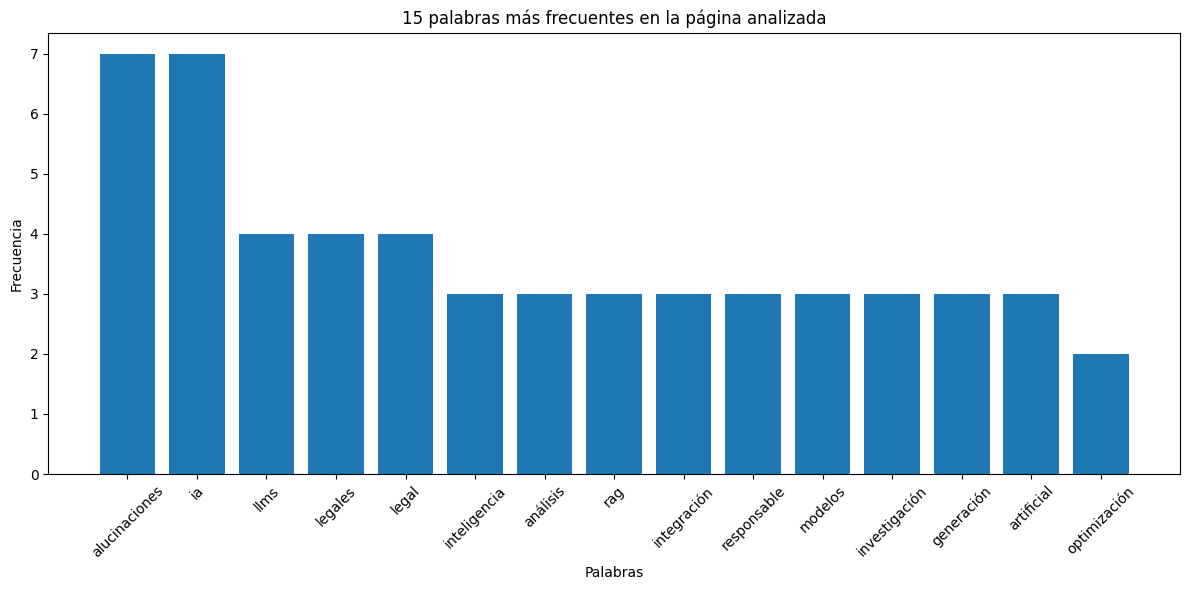

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Contar frecuencias
frecuencias = Counter(tokens_limpios)

# Obtener las 15 palabras más frecuentes
top_15 = frecuencias.most_common(15)

# Separar palabras y cantidades
palabras = [palabra for palabra, frecuencia in top_15]
cantidades = [frecuencia for palabra, frecuencia in top_15]

# Graficar
plt.figure(figsize=(12, 6))
plt.bar(palabras, cantidades)
plt.xticks(rotation=45)
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.title("15 palabras más frecuentes en la página analizada")
plt.tight_layout()
plt.show()

### Comentario sobre posibles stopwords adicionales

Aparecen algunas palabras que, aunque no fueron eliminadas por la lista de stopwords de nltk, igualmente podrían considerarse poco relevantes.

Esto pasa porque las stopwords que vienen por defecto son generales y no siempre se ajustan del todo al contenido del documento. Por eso, pueden quedar palabras que se repiten bastante pero que no aportan demasiado al significado del texto.

También se ven algunas palabras en inglés, ya que el documento mezcla ambos idiomas. Como usé stopwords en español, esas palabras no se eliminaron automáticamente.

Por eso, en un análisis más avanzado, sería útil armar una lista de stopwords más personalizada, agregando palabras poco importantes según el contexto e incluso incluyendo stopwords en inglés.